# GoPay Google Play Review - TF-IDF

**Author:** Muhammad Razan Parisya Putra  
**Notebook:** `05 - TF-IDF`

This notebook continues from the preprocessing covered in [4-Gopay-Review-BoW.ipynb](https://drive.google.com/file/d/1l37wOvx0wET9TVxvgevOi9ED6JPplf2W/view?usp=sharing)

#### Install dan Import Library

In [ ]:
pip install -U nltk tensorflow_hub xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.6 MB/s eta 0:00:00
  Attempting uninstall: nltk
    Found existing installation: nltk 3.9.1
    Uninstalling nltk-3.9.1:
      Successfully uninstalled nltk-3.9.1


In [ ]:
import pandas as pd
import numpy as np
import torch
import nltk
from collections import Counter
from timeit import default_timer as timer

import tensorflow as tf
import tensorflow_hub as hub

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from scipy.sparse import vstack

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print('Import selesai.')

Import selesai.


In [ ]:
nltk.download('stopwords')
nltk.download('words')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

#### Cek Ketersediaan GPU

In [ ]:
is_cuda = torch.cuda.is_available()
device  = torch.device('cuda') if is_cuda else torch.device('cpu')
print(f'Device : {device}')
print(f'GPU    : {is_cuda}')
if is_cuda:
    print(f'Nama GPU: {torch.cuda.get_device_name(0)}')

# Cek TF GPU
tf_gpus = tf.config.list_physical_devices('GPU')
print(f'TF GPU tersedia: {len(tf_gpus) > 0} ({len(tf_gpus)} device)')

Device : cuda
GPU    : True
Nama GPU: Tesla T4
TF GPU tersedia: True (1 device)


#### Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Tugas 1/Dataset/gopay_reviews_sentiment.csv')
print(f'Total data: {df.shape[0]:,} baris, {df.shape[1]} kolom')
print()
print('Distribusi sentimen awal (full dataset):')
print(df['sentiment'].value_counts())
print()
print('Proporsi kelas:')
print(df['sentiment'].value_counts(normalize=True).round(4))

Total data: 209,311 baris, 11 kolom

Distribusi sentimen awal (full dataset):
sentiment
positive    141373
negative     58780
neutral       9158
Name: count, dtype: int64

Proporsi kelas:
sentiment
positive    0.6754
negative    0.2808
neutral     0.0438
Name: proportion, dtype: float64


#### Analisis Class Imbalance & Alasan Subsampling

Dataset GoPay memiliki 216k baris dengan distribusi yang sangat tidak seimbang.
Memproses seluruh data akan membutuhkan waktu yang sangat lama terutama pada tahap USE embedding (2-3 menit) dan TF-IDF + USE combined (3.6 GB RAM sekaligus).

**Strategi yang diterapkan:**
- **Stratified Subsampling 60k**: mengambil sampel proporsional dari setiap kelas sehingga
  distribusi kelas tetap terjaga. Ini berbeda dari random sampling biasa.
- **Minimum kuota per kelas**: kelas netral yang sangat sedikit dijamin mendapat
  representasi yang cukup dengan kuota minimum 3k sampel.

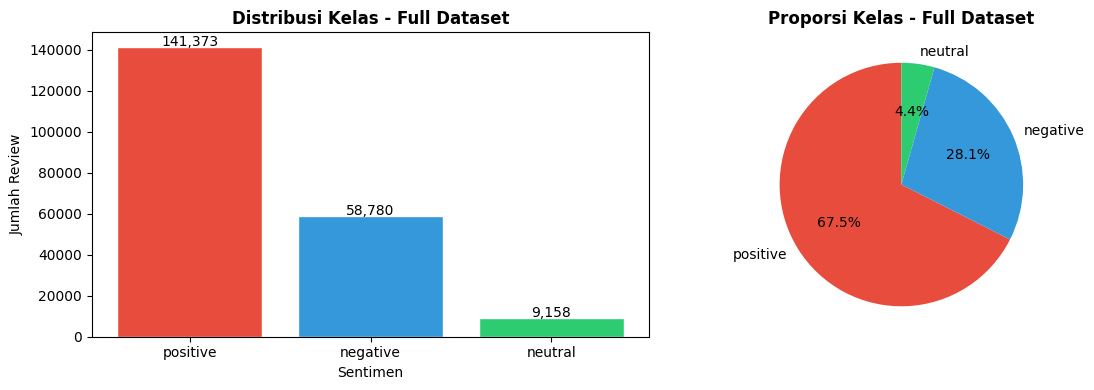

Rasio positive:neutral = 15.4:1


In [ ]:
# Visualisasi distribusi kelas sebelum subsampling
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sentiment_counts = df['sentiment'].value_counts()
colors = ['#e74c3c', '#3498db', '#2ecc71']

axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Distribusi Kelas - Full Dataset', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentimen')
axes[0].set_ylabel('Jumlah Review')
for i, (lbl, val) in enumerate(sentiment_counts.items()):
    axes[0].text(i, val + 500, f'{val:,}', ha='center', fontsize=10)

axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index,
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporsi Kelas - Full Dataset', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Tugas 1/Images/Class-Imbalance-Distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Rasio positive:neutral = {sentiment_counts["positive"]/sentiment_counts["neutral"]:.1f}:1')

#### Stratified Subsampling

Mengambil 60.000 sampel representatif dari full dataset menggunakan stratified sampling.
Kelas netral dijamin minimum 3.000 sampel agar model punya cukup data untuk belajar
membedakan sentimen netral dari positif/negatif.

In [ ]:
TOTAL_SAMPLE = 60_000
MIN_PER_CLASS = 8_000  # jamin kelas minoritas (neutral) cukup terwakili

# Filter data valid terlebih dahulu
df_valid = df[
    df['final_text'].notna() &
    (df['final_text'].astype(str).str.strip() != '')
].copy()
print(f'Data valid: {len(df_valid):,} dari {len(df):,}')

# Hitung kuota per kelas (proporsional, dengan floor pada kelas minoritas)
class_counts = df_valid['sentiment'].value_counts()
total_valid  = len(df_valid)

quotas = {}
for cls in class_counts.index:
    proportional = int(TOTAL_SAMPLE * (class_counts[cls] / total_valid))
    quotas[cls] = max(proportional, MIN_PER_CLASS)

# Koreksi jika total melebihi TOTAL_SAMPLE
current_total = sum(quotas.values())
if current_total > TOTAL_SAMPLE:
    # Kurangi dari kelas terbesar
    biggest = max(quotas, key=quotas.get)
    quotas[biggest] -= (current_total - TOTAL_SAMPLE)

print()
print('Kuota sampel per kelas:')
for cls, q in quotas.items():
    avail = class_counts[cls]
    print(f'  {cls:<12}: {q:,} dari {avail:,} yang tersedia ({q/avail*100:.1f}%)')
print(f'  Total     : {sum(quotas.values()):,}')

Data valid: 209,311 dari 209,311

Kuota sampel per kelas:
  positive    : 35,151 dari 141,373 yang tersedia (24.9%)
  negative    : 16,849 dari 58,780 yang tersedia (28.7%)
  neutral     : 8,000 dari 9,158 yang tersedia (87.4%)
  Total     : 60,000


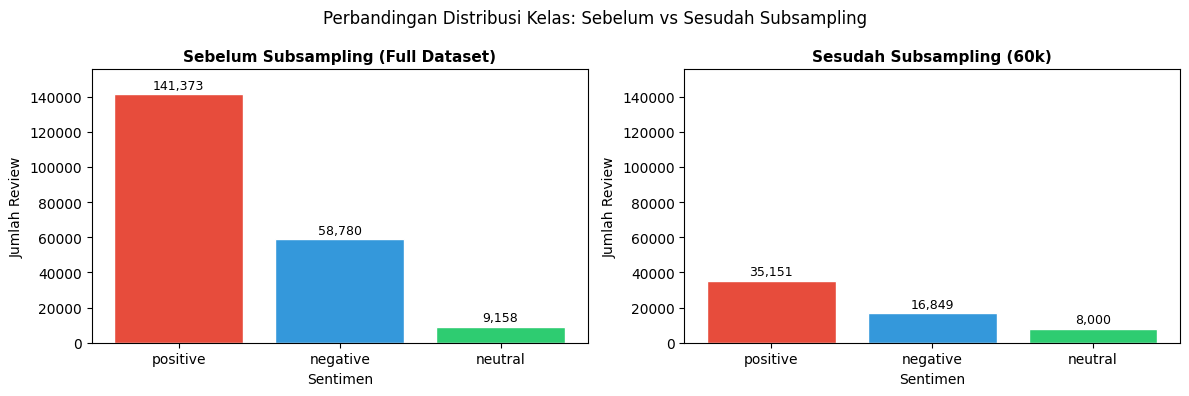

In [ ]:
# Visualisasi perbandingan distribusi sebelum vs sesudah

# Create df_sampled using df_valid and quotas
df_sampled_list = []
for cls, q in quotas.items():
    class_df = df_valid[df_valid['sentiment'] == cls]
    n_sample = min(q, len(class_df))
    df_sampled_list.append(class_df.sample(n=n_sample, random_state=42))

df_sampled = pd.concat(df_sampled_list).sample(frac=1, random_state=42).reset_index(drop=True)

# Original code continues below
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before = df['sentiment'].value_counts()
after  = df_sampled['sentiment'].value_counts()

max_y = max(before.max(), after.max()) * 1.1  # supaya skala sama

for ax, data, title in zip(
    axes,
    [before, after],
    ['Sebelum Subsampling (Full Dataset)', 'Sesudah Subsampling (60k)']
):
    ax.bar(data.index, data.values, color=colors, edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Sentimen')
    ax.set_ylabel('Jumlah Review')
    ax.set_ylim(0, max_y)   # <- ini yang membuat grafik terlihat berbeda

    for i, (lbl, v) in enumerate(data.items()):
        ax.text(i, v + max_y*0.02, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Perbandingan Distribusi Kelas: Sebelum vs Sesudah Subsampling', fontsize=12)
plt.tight_layout()
plt.show()

#### Label Encoding dan Train-Test Split

In [ ]:
label_encode = LabelEncoder()
Y_encoded = label_encode.fit_transform(df_sampled['sentiment'])

CLASS_NAMES = list(label_encode.classes_)
print(f'Label Mapping : {CLASS_NAMES} -> {label_encode.transform(CLASS_NAMES)}')
print('Catatan       : 0 = negative, 1 = neutral, 2 = positive')

Label Mapping : ['negative', 'neutral', 'positive'] -> [0 1 2]
Catatan       : 0 = negative, 1 = neutral, 2 = positive


In [ ]:
x_data = df_sampled['final_text'].astype(str)
y_data = Y_encoded

xtrain, xtest, ytrain, ytest = train_test_split(
    x_data, y_data,
    test_size=0.2,
    random_state=42,
    stratify=y_data
)

print(f'Training set : {len(xtrain):,} sampel')
print(f'Testing set  : {len(xtest):,} sampel')
print()
for split_name, y_split in [('Train', ytrain), ('Test', ytest)]:
    print(f'{split_name} distribution:')
    counts = pd.Series(y_split).value_counts().sort_index()
    for idx, cnt in counts.items():
        print(f'  {CLASS_NAMES[idx]:<12}: {cnt:,} ({cnt/len(y_split)*100:.1f}%)')
    print()

Training set : 48,000 sampel
Testing set  : 12,000 sampel

Train distribution:
  negative    : 13,479 (28.1%)
  neutral     : 6,400 (13.3%)
  positive    : 28,121 (58.6%)

Test distribution:
  negative    : 3,370 (28.1%)
  neutral     : 1,600 (13.3%)
  positive    : 7,030 (58.6%)



#### Analisis Kosakata Training Data

In [ ]:
word_counts = Counter(' '.join(str(t) for t in xtrain).split())
print(f'Total kata unik: {len(word_counts):,}')
print()
print('50 kata paling sering:')
for word, count in word_counts.most_common(50):
    print(f'  {word}: {count:,}')

Total kata unik: 9,655

50 kata paling sering:
  bagus: 5,408
  mudah: 5,247
  saldo: 4,675
  pakai: 4,557
  transaksi: 4,529
  masuk: 4,500
  bantu: 4,257
  banget: 3,775
  bayar: 3,774
  transfer: 3,051
  kasih: 2,902
  mantap: 2,796
  top: 2,773
  uang: 2,585
  cepat: 2,534
  pinjam: 2,248
  baik: 1,861
  akun: 1,841
  kalo: 1,742
  beli: 1,659
  aman: 1,648
  coba: 1,506
  moga: 1,481
  bank: 1,397
  dana: 1,376
  suka: 1,344
  terima: 1,308
  promo: 1,286
  ribet: 1,282
  pulsa: 1,239
  gratis: 1,238
  pas: 1,221
  murah: 1,210
  hilang: 1,144
  kirim: 1,135
  guna: 1,130
  proses: 1,101
  kecewa: 1,063
  tunggu: 1,047
  susah: 964
  isi: 948
  potong: 932
  puas: 893
  keren: 889
  layan: 887
  data: 887
  fitur: 886
  lancar: 866
  gagal: 859
  admin: 853


#### Inisialisasi Classifier dan Fungsi Evaluasi

Semua classifier yang mendukung `class_weight` diinisialisasi dengan `class_weight='balanced'`.
XGBoost menggunakan `compute_sample_weight` yang dihitung sekali dan dipakai di semua section.

In [ ]:
# Hitung sample weights untuk XGBoost - dihitung sekali, dipakai di semua section
sample_weights = compute_sample_weight(class_weight='balanced', y=ytrain)

print('Sample weight per kelas (XGBoost):')
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    w = sample_weights[ytrain == cls_idx][0]
    print(f'  {cls_name:<12}: {w:.4f}')

Sample weight per kelas (XGBoost):
  negative    : 1.1870
  neutral     : 2.5000
  positive    : 0.5690


In [ ]:
def init_classifiers():
    """
    Buat instance classifier baru. Dipanggil di awal setiap section embedding
    untuk memastikan tidak ada state yang terbawa dari training sebelumnya.

    Catatan class_weight:
    - LinearSVC, LogisticRegression, RandomForest: class_weight='balanced'
    - XGBoost: menggunakan sample_weight saat .fit() karena tidak support parameter class_weight
    - MultinomialNB: tidak support class_weight, hanya tersedia untuk TF-IDF
    """
    svm = LinearSVC(max_iter=2000, random_state=42, class_weight='balanced')
    lr  = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', n_jobs=-1)
    nb  = MultinomialNB()
    xgb = XGBClassifier(
        objective='multi:softmax', eval_metric='mlogloss',
        num_class=len(CLASS_NAMES), random_state=42,
        n_estimators=100, learning_rate=0.1,
        tree_method='hist',  # lebih cepat dari default 'auto'
        device='cuda' if torch.cuda.is_available() else 'cpu'
    )
    rfc = RandomForestClassifier(
        n_estimators=100, max_depth=15, max_features='sqrt',
        min_samples_leaf=2, n_jobs=-1, random_state=42,
        class_weight='balanced'
    )
    return svm, lr, nb, xgb, rfc

In [ ]:
def evaluate_model(model, xtest_data, ytest_labels, target_names=CLASS_NAMES):
    """
    Evaluasi model dan return 7 nilai:
    y_pred, accuracy, precision, recall, f1 (weighted), report, confusion_matrix
    """
    y_pred    = model.predict(xtest_data)
    accuracy  = accuracy_score(ytest_labels, y_pred)
    precision = precision_score(ytest_labels, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(ytest_labels, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(ytest_labels, y_pred, average='weighted', zero_division=0)
    report    = classification_report(ytest_labels, y_pred, target_names=target_names, zero_division=0)
    cm        = confusion_matrix(ytest_labels, y_pred)
    return y_pred, accuracy, precision, recall, f1, report, cm

batch_size = 1000
print('Setup selesai. Siap mulai training.')

Setup selesai. Siap mulai training.


---
## Bagian 1: Feature Extraction

Proses feature extraction dilakukan dalam **dua langkah terpisah** agar terlihat jelas:

| Langkah | Komponen | Apa yang Dilakukan |
|---------|----------|--------------------|
| 1 | **CountVectorizer (BoW)** | Mengubah teks menjadi angka: menghitung frekuensi setiap kata di setiap review |
| 2 | **TfidfTransformer** | Menerapkan bobot IDF di atas matriks BoW: kata umum bobotnya turun, kata langka bobotnya naik |

Perlu dicatat bahwa BoW di notebook 04 di-fit pada **seluruh dataset** untuk tujuan eksplorasi.
Di sini, BoW di-fit **hanya pada data training** untuk menghindari data leakage ke data test.

### Langkah 1: Bag of Words (CountVectorizer)

Mengubah teks menjadi matriks angka. Setiap baris = satu review, setiap kolom = satu kata unik,
setiap sel = berapa kali kata itu muncul di review tersebut.

Ini adalah "bahan baku" yang nantinya akan diberi bobot oleh TF-IDF.

In [ ]:
print('=' * 65)
print('LANGKAH 1 : Bag of Words (CountVectorizer)')
print('=' * 65)

# Fit hanya pada training data untuk menghindari data leakage
bow_vec = CountVectorizer(max_features=5000)
bow_vec.fit(xtrain.tolist())

# Transform training dan test data
start = timer()
xtrain_bow = vstack([
    bow_vec.transform(xtrain.tolist()[i:i+batch_size])
    for i in range(0, len(xtrain), batch_size)
])
xtest_bow = vstack([
    bow_vec.transform(xtest.tolist()[i:i+batch_size])
    for i in range(0, len(xtest), batch_size)
])
elapsed = timer() - start

vocab = bow_vec.get_feature_names_out()

print(f'BoW train    : {xtrain_bow.shape}')
print(f'BoW test     : {xtest_bow.shape}')
print(f'Vocabulary   : {len(vocab):,} terms')
print(f'Non-zero     : {xtrain_bow.nnz:,} entries')
print(f'Sparsity     : {(1 - xtrain_bow.nnz / (xtrain_bow.shape[0] * xtrain_bow.shape[1])) * 100:.2f}%')
print(f'Waktu        : {elapsed:.2f}s')

# Top 10 kata paling sering (frekuensi mentah)
freq = np.asarray(xtrain_bow.sum(axis=0)).flatten()
top10 = freq.argsort()[::-1][:10]
print(f'\nTop 10 kata BoW (frekuensi mentah):')
for idx in top10:
    print(f'  {vocab[idx]:20s} -> {int(freq[idx]):,}')

### Langkah 2: TF-IDF (TfidfTransformer)

Mengambil matriks BoW dari langkah sebelumnya, lalu menerapkan bobot IDF:
- Kata yang muncul di hampir semua review (seperti "gopay", "aplikasi") -> **bobot turun**
- Kata yang jarang dan spesifik (seperti "error", "crash") -> **bobot naik**

Hasilnya adalah matriks TF-IDF yang lebih akurat merepresentasikan pentingnya setiap kata.

In [ ]:
print('=' * 65)
print('LANGKAH 2 : TF-IDF (TfidfTransformer)')
print('=' * 65)

# Fit pada matriks BoW training, lalu transform keduanya
tfidf_transformer = TfidfTransformer()
tfidf_transformer.fit(xtrain_bow)

start = timer()
xtrain_tfidf = tfidf_transformer.transform(xtrain_bow)
xtest_tfidf  = tfidf_transformer.transform(xtest_bow)
elapsed = timer() - start

print(f'TF-IDF train : {xtrain_tfidf.shape}')
print(f'TF-IDF test  : {xtest_tfidf.shape}')
print(f'Tipe matrix  : {type(xtrain_tfidf).__name__} (sparse)')
print(f'Waktu        : {elapsed:.2f}s')

### Perbandingan Output: BoW vs TF-IDF

Lihat bagaimana nilai berubah setelah bobot IDF diterapkan.
Kata umum yang frekuensinya tinggi di BoW akan mendapat skor TF-IDF yang rendah,
sedangkan kata langka yang spesifik akan mendapat skor lebih tinggi.

In [ ]:
# Ambil review pertama dari training set
bow_row   = np.asarray(xtrain_bow[0].todense()).flatten()
tfidf_row = np.asarray(xtrain_tfidf[0].todense()).flatten()

# Ambil kata-kata yang muncul di review ini (non-zero)
nonzero = np.where(bow_row > 0)[0]
nonzero_sorted = nonzero[bow_row[nonzero].argsort()[::-1]]

print('Perbandingan BoW vs TF-IDF (review pertama):')
print(f'Review: "{xtrain.iloc[0][:80]}..."')
print()
print(f'{"Kata":20s} {"BoW (mentah)":>14s} {"TF-IDF (berbobot)":>18s}')
print('-' * 55)
for idx in nonzero_sorted[:10]:
    print(f'{vocab[idx]:20s} {int(bow_row[idx]):>14,} {tfidf_row[idx]:>18.4f}')

print()
print('Catatan:')
print('  - Kata umum: frekuensi BoW tinggi, tapi skor TF-IDF rendah')
print('  - Kata langka: frekuensi BoW rendah, tapi skor TF-IDF relatif tinggi')
print()
print('Feature extraction selesai. Siap untuk training classifier.')

In [ ]:
# Training semua 5 classifier
svm_c, lr_c, nb_c, xgb_c, rfc_c = init_classifiers()
print('Training classifier TF-IDF...')
print()

start = timer(); svm_tfidf = svm_c.fit(xtrain_tfidf, ytrain)
print(f'  Linear SVM       : {timer()-start:.2f}s')

start = timer(); lr_tfidf = lr_c.fit(xtrain_tfidf, ytrain)
print(f'  Logistic Reg     : {timer()-start:.2f}s')

start = timer(); nb_tfidf = nb_c.fit(xtrain_tfidf, ytrain)
print(f'  Naive Bayes      : {timer()-start:.2f}s')

start = timer(); xgb_tfidf = xgb_c.fit(xtrain_tfidf, ytrain, sample_weight=sample_weights)
print(f'  XGBoost          : {timer()-start:.2f}s')

start = timer(); rfc_tfidf = rfc_c.fit(xtrain_tfidf, ytrain)
print(f'  Random Forest    : {timer()-start:.2f}s')
print()
print('Training TF-IDF selesai.')

Training classifier TF-IDF...

  Linear SVM       : 1.15s
  Logistic Reg     : 3.77s
  Naive Bayes      : 0.01s
  XGBoost          : 4.23s
  Random Forest    : 1.33s

Training TF-IDF selesai.


### Linear SVM - TF-IDF

In [ ]:
print('--- Linear SVM (TF-IDF) ---')
y_pred_svm, acc_svm, prec_svm, rec_svm, f1_svm, rep_svm, cm_svm = \
    evaluate_model(svm_tfidf, xtest_tfidf, ytest)

print('Contoh 15 prediksi:')
for a, p in zip(list(ytest[:15]), list(y_pred_svm[:15])):
    status = 'OK' if a == p else 'X'
    print(f'  [{status}] Aktual: {CLASS_NAMES[a]:<12} | Prediksi: {CLASS_NAMES[p]}')
print(f'\nAkurasi  : {acc_svm:.4f}')
print(f'Presisi  : {prec_svm:.4f}')
print(f'Recall   : {rec_svm:.4f}')
print(f'F1-Score : {f1_svm:.4f}')
print('\nLaporan Klasifikasi:')
print(rep_svm)
print('Confusion Matrix:')
print(cm_svm)

--- Linear SVM (TF-IDF) ---
Contoh 15 prediksi:
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: neutral      | Prediksi: positive
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: negative     | Prediksi: negative
  [X] Aktual: positive     | Prediksi: neutral
  [X] Aktual: negative     | Prediksi: positive
  [OK] Aktual: negative     | Prediksi: negative
  [X] Aktual: positive     | Prediksi: negative
  [X] Aktual: negative     | Prediksi: neutral

Akurasi  : 0.7598
Presisi  : 0.7609
Recall   : 0.7598
F1-Score : 0.7600

Laporan Klasifikasi:
              precision    recall  f1-score   support

    negative       0.70      0.76      0.73      3370
     neutral       0

### Logistic Regression - TF-IDF

In [ ]:
print('--- Logistic Regression (TF-IDF) ---')
y_pred_lr, acc_lr, prec_lr, rec_lr, f1_lr, rep_lr, cm_lr = \
    evaluate_model(lr_tfidf, xtest_tfidf, ytest)

print('Contoh 15 prediksi:')
for a, p in zip(list(ytest[:15]), list(y_pred_lr[:15])):
    status = 'OK' if a == p else 'X'
    print(f'  [{status}] Aktual: {CLASS_NAMES[a]:<12} | Prediksi: {CLASS_NAMES[p]}')
print(f'\nAkurasi  : {acc_lr:.4f}')
print(f'Presisi  : {prec_lr:.4f}')
print(f'Recall   : {rec_lr:.4f}')
print(f'F1-Score : {f1_lr:.4f}')
print('\nLaporan Klasifikasi:')
print(rep_lr)
print('Confusion Matrix:')
print(cm_lr)

--- Logistic Regression (TF-IDF) ---
Contoh 15 prediksi:
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: neutral      | Prediksi: neutral
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: negative     | Prediksi: negative
  [X] Aktual: positive     | Prediksi: neutral
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: negative     | Prediksi: negative
  [X] Aktual: positive     | Prediksi: negative
  [X] Aktual: negative     | Prediksi: neutral

Akurasi  : 0.7405
Presisi  : 0.7813
Recall   : 0.7405
F1-Score : 0.7570

Laporan Klasifikasi:
              precision    recall  f1-score   support

    negative       0.73      0.71      0.72      3370
     neutr

### Naive Bayes - TF-IDF

In [ ]:
print('--- Naive Bayes (TF-IDF) ---')
y_pred_nb, acc_nb, prec_nb, rec_nb, f1_nb, rep_nb, cm_nb = \
    evaluate_model(nb_tfidf, xtest_tfidf, ytest)

print('Contoh 15 prediksi:')
for a, p in zip(list(ytest[:15]), list(y_pred_nb[:15])):
    status = 'OK' if a == p else 'X'
    print(f'  [{status}] Aktual: {CLASS_NAMES[a]:<12} | Prediksi: {CLASS_NAMES[p]}')
print(f'\nAkurasi  : {acc_nb:.4f}')
print(f'Presisi  : {prec_nb:.4f}')
print(f'Recall   : {rec_nb:.4f}')
print(f'F1-Score : {f1_nb:.4f}')
print('\nLaporan Klasifikasi:')
print(rep_nb)
print('Confusion Matrix:')
print(cm_nb)

--- Naive Bayes (TF-IDF) ---
Contoh 15 prediksi:
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: neutral      | Prediksi: positive
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: negative     | Prediksi: negative
  [X] Aktual: positive     | Prediksi: negative
  [X] Aktual: negative     | Prediksi: positive

Akurasi  : 0.7768
Presisi  : 0.7342
Recall   : 0.7768
F1-Score : 0.7321

Laporan Klasifikasi:
              precision    recall  f1-score   support

    negative       0.67      0.85      0.75      3370
     neutral   

### XGBoost - TF-IDF

In [ ]:
print('--- XGBoost (TF-IDF) ---')
y_pred_xgboost, acc_xgboost, prec_xgboost, rec_xgboost, f1_xgboost, rep_xgboost, cm_xgboost = \
    evaluate_model(xgb_tfidf, xtest_tfidf, ytest)

print('Contoh 15 prediksi:')
for a, p in zip(list(ytest[:15]), list(y_pred_xgboost[:15])):
    status = 'OK' if a == p else 'X'
    print(f'  [{status}] Aktual: {CLASS_NAMES[a]:<12} | Prediksi: {CLASS_NAMES[p]}')
print(f'\nAkurasi  : {acc_xgboost:.4f}')
print(f'Presisi  : {prec_xgboost:.4f}')
print(f'Recall   : {rec_xgboost:.4f}')
print(f'F1-Score : {f1_xgboost:.4f}')
print('\nLaporan Klasifikasi:')
print(rep_xgboost)
print('Confusion Matrix:')
print(cm_xgboost)

--- XGBoost (TF-IDF) ---
Contoh 15 prediksi:
  [X] Aktual: negative     | Prediksi: neutral
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: neutral      | Prediksi: neutral
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: negative     | Prediksi: neutral
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: negative     | Prediksi: neutral
  [OK] Aktual: negative     | Prediksi: negative
  [X] Aktual: positive     | Prediksi: negative
  [X] Aktual: negative     | Prediksi: positive

Akurasi  : 0.6558
Presisi  : 0.7708
Recall   : 0.6558
F1-Score : 0.6948

Laporan Klasifikasi:
              precision    recall  f1-score   support

    negative       0.72      0.63      0.67      3370
     neutral       0.23  

### Random Forest - TF-IDF

In [ ]:
print('--- Random Forest (TF-IDF) ---')
y_pred_rfc, acc_rfc, prec_rfc, rec_rfc, f1_rfc, rep_rfc, cm_rfc = \
    evaluate_model(rfc_tfidf, xtest_tfidf, ytest)

print('Contoh 15 prediksi:')
for a, p in zip(list(ytest[:15]), list(y_pred_rfc[:15])):
    status = 'OK' if a == p else 'X'
    print(f'  [{status}] Aktual: {CLASS_NAMES[a]:<12} | Prediksi: {CLASS_NAMES[p]}')
print(f'\nAkurasi  : {acc_rfc:.4f}')
print(f'Presisi  : {prec_rfc:.4f}')
print(f'Recall   : {rec_rfc:.4f}')
print(f'F1-Score : {f1_rfc:.4f}')
print('\nLaporan Klasifikasi:')
print(rep_rfc)
print('Confusion Matrix:')
print(cm_rfc)

--- Random Forest (TF-IDF) ---
Contoh 15 prediksi:
  [X] Aktual: negative     | Prediksi: neutral
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: neutral      | Prediksi: positive
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: negative     | Prediksi: neutral
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: negative     | Prediksi: neutral
  [OK] Aktual: negative     | Prediksi: negative
  [X] Aktual: positive     | Prediksi: negative
  [X] Aktual: negative     | Prediksi: positive

Akurasi  : 0.7283
Presisi  : 0.7321
Recall   : 0.7283
F1-Score : 0.7300

Laporan Klasifikasi:
              precision    recall  f1-score   support

    negative       0.70      0.66      0.68      3370
     neutral       

#### Perbandingan Akurasi - TF-IDF

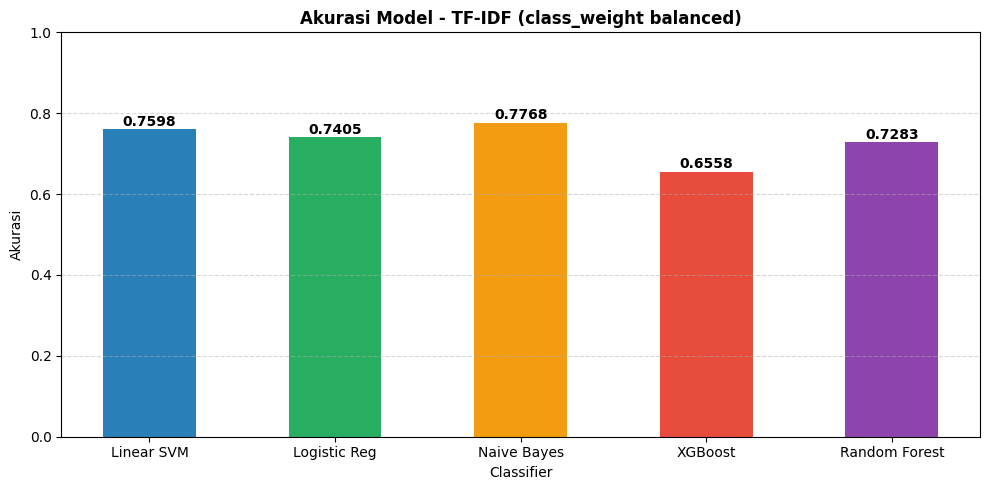

In [ ]:
names_tfidf = ['Linear SVM','Logistic Reg','Naive Bayes','XGBoost','Random Forest']
accs_tfidf  = [acc_svm, acc_lr, acc_nb, acc_xgboost, acc_rfc]

plt.figure(figsize=(10, 5))
bars = plt.bar(names_tfidf, accs_tfidf,
               color=['#2980b9','#27ae60','#f39c12','#e74c3c','#8e44ad'], width=0.5)
plt.title('Akurasi Model - TF-IDF (class_weight balanced)', fontsize=12, fontweight='bold')
plt.xlabel('Classifier'); plt.ylabel('Akurasi')
plt.ylim(0, 1); plt.grid(axis='y', linestyle='--', alpha=0.5)
for bar, acc in zip(bars, accs_tfidf):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
             f'{acc:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Tugas 1/Images/TF-IDF-Accuracy-Comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## Bagian 2: Universal Sentence Encoder (USE)

USE menghasilkan embedding dense 512 dimensi yang menangkap makna semantik kalimat
secara keseluruhan, bukan hanya frekuensi kata. Model ini dilatih untuk Bahasa Inggris,
sehingga performanya pada Bahasa Indonesia mungkin lebih rendah dibanding TF-IDF.

Dengan subsampling 60k, proses embedding jauh lebih cepat dibanding full dataset.
Estimasi waktu: ~5-8 detik untuk train, ~1-2 detik untuk test.

**Catatan:** Naive Bayes dikecualikan karena `MultinomialNB` tidak menerima
nilai negatif yang ada dalam embedding USE.

In [ ]:
print('=' * 65)
print('BAGIAN 2 : UNIVERSAL SENTENCE ENCODER (USE)')
print('=' * 65)

print('Memuat USE dari TensorFlow Hub...')
start = timer()
use_embed = hub.load('https://tfhub.dev/google/universal-sentence-encoder/4')
print(f'USE dimuat dalam {timer()-start:.2f} detik')

BAGIAN 2 : UNIVERSAL SENTENCE ENCODER (USE)
Memuat USE dari TensorFlow Hub...
USE dimuat dalam 16.99 detik


In [ ]:
# Embedding dengan batching - jauh lebih efisien dari full dataset
print('Embedding data training...')
start = timer()
xtrain_use = np.vstack([
    use_embed(xtrain.tolist()[i:i+batch_size]).numpy()
    for i in range(0, len(xtrain), batch_size)
])
print(f'Train USE : {xtrain_use.shape} | {timer()-start:.2f}s')
print(f'Estimasi memori: {xtrain_use.nbytes / 1e6:.1f} MB')

print('\nEmbedding data testing...')
start = timer()
xtest_use = np.vstack([
    use_embed(xtest.tolist()[i:i+batch_size]).numpy()
    for i in range(0, len(xtest), batch_size)
])
print(f'Test USE  : {xtest_use.shape} | {timer()-start:.2f}s')

Embedding data training...
Train USE : (48000, 512) | 7.90s
Estimasi memori: 98.3 MB

Embedding data testing...
Test USE  : (12000, 512) | 0.55s


In [ ]:
# Training 4 classifier USE (tanpa Naive Bayes)
svm_c, lr_c, _, xgb_c, rfc_c = init_classifiers()
print('Training classifier USE...')
print()

start = timer(); svm_use = svm_c.fit(xtrain_use, ytrain)
print(f'  Linear SVM    : {timer()-start:.2f}s')

start = timer(); lr_use = lr_c.fit(xtrain_use, ytrain)
print(f'  Logistic Reg  : {timer()-start:.2f}s')

start = timer(); xgb_use = xgb_c.fit(xtrain_use, ytrain, sample_weight=sample_weights)
print(f'  XGBoost       : {timer()-start:.2f}s')

start = timer(); rfc_use = rfc_c.fit(xtrain_use, ytrain)
print(f'  Random Forest : {timer()-start:.2f}s')
print()
print('Training USE selesai.')

Training classifier USE...

  Linear SVM    : 42.20s
  Logistic Reg  : 10.57s
  XGBoost       : 10.50s
  Random Forest : 114.35s

Training USE selesai.


### Linear SVM - USE

In [ ]:
print('--- Linear SVM (USE) ---')
y_pred_svm_use, acc_svm_use, prec_svm_use, rec_svm_use, f1_svm_use, rep_svm_use, cm_svm_use = \
    evaluate_model(svm_use, xtest_use, ytest)

print('Contoh 15 prediksi:')
for a, p in zip(list(ytest[:15]), list(y_pred_svm_use[:15])):
    status = 'OK' if a == p else 'X'
    print(f'  [{status}] Aktual: {CLASS_NAMES[a]:<12} | Prediksi: {CLASS_NAMES[p]}')
print(f'\nAkurasi  : {acc_svm_use:.4f}')
print(f'Presisi  : {prec_svm_use:.4f}')
print(f'Recall   : {rec_svm_use:.4f}')
print(f'F1-Score : {f1_svm_use:.4f}')
print('\nLaporan Klasifikasi:')
print(rep_svm_use)
print('Confusion Matrix:')
print(cm_svm_use)

--- Linear SVM (USE) ---
Contoh 15 prediksi:
  [OK] Aktual: negative     | Prediksi: negative
  [X] Aktual: positive     | Prediksi: neutral
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: neutral      | Prediksi: negative
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: negative     | Prediksi: positive
  [X] Aktual: negative     | Prediksi: positive
  [X] Aktual: positive     | Prediksi: negative
  [OK] Aktual: negative     | Prediksi: negative

Akurasi  : 0.7121
Presisi  : 0.6914
Recall   : 0.7121
F1-Score : 0.6977

Laporan Klasifikasi:
              precision    recall  f1-score   support

    negative       0.61      0.72      0.66      3370
     neutral       0.3

### Logistic Regression - USE

In [ ]:
print('--- Logistic Regression (USE) ---')
y_pred_lr_use, acc_lr_use, prec_lr_use, rec_lr_use, f1_lr_use, rep_lr_use, cm_lr_use = \
    evaluate_model(lr_use, xtest_use, ytest)

print('Contoh 15 prediksi:')
for a, p in zip(list(ytest[:15]), list(y_pred_lr_use[:15])):
    status = 'OK' if a == p else 'X'
    print(f'  [{status}] Aktual: {CLASS_NAMES[a]:<12} | Prediksi: {CLASS_NAMES[p]}')
print(f'\nAkurasi  : {acc_lr_use:.4f}')
print(f'Presisi  : {prec_lr_use:.4f}')
print(f'Recall   : {rec_lr_use:.4f}')
print(f'F1-Score : {f1_lr_use:.4f}')
print('\nLaporan Klasifikasi:')
print(rep_lr_use)
print('Confusion Matrix:')
print(cm_lr_use)

--- Logistic Regression (USE) ---
Contoh 15 prediksi:
  [OK] Aktual: negative     | Prediksi: negative
  [X] Aktual: positive     | Prediksi: neutral
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: neutral      | Prediksi: neutral
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: negative     | Prediksi: neutral
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: negative     | Prediksi: positive
  [X] Aktual: negative     | Prediksi: positive
  [X] Aktual: positive     | Prediksi: negative
  [OK] Aktual: negative     | Prediksi: negative

Akurasi  : 0.6539
Presisi  : 0.7084
Recall   : 0.6539
F1-Score : 0.6754

Laporan Klasifikasi:
              precision    recall  f1-score   support

    negative       0.61      0.64      0.63      3370
     neutral   

### XGBoost - USE

In [ ]:
print('--- XGBoost (USE) ---')
y_pred_xgboost_use, acc_xgboost_use, prec_xgboost_use, rec_xgboost_use, f1_xgboost_use, rep_xgboost_use, cm_xgboost_use = \
    evaluate_model(xgb_use, xtest_use, ytest)

print('Contoh 15 prediksi:')
for a, p in zip(list(ytest[:15]), list(y_pred_xgboost_use[:15])):
    status = 'OK' if a == p else 'X'
    print(f'  [{status}] Aktual: {CLASS_NAMES[a]:<12} | Prediksi: {CLASS_NAMES[p]}')
print(f'\nAkurasi  : {acc_xgboost_use:.4f}')
print(f'Presisi  : {prec_xgboost_use:.4f}')
print(f'Recall   : {rec_xgboost_use:.4f}')
print(f'F1-Score : {f1_xgboost_use:.4f}')
print('\nLaporan Klasifikasi:')
print(rep_xgboost_use)
print('Confusion Matrix:')
print(cm_xgboost_use)

--- XGBoost (USE) ---
Contoh 15 prediksi:
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: neutral      | Prediksi: negative
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: negative     | Prediksi: neutral
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: negative     | Prediksi: positive
  [X] Aktual: negative     | Prediksi: positive
  [X] Aktual: positive     | Prediksi: negative
  [OK] Aktual: negative     | Prediksi: negative

Akurasi  : 0.6886
Presisi  : 0.7095
Recall   : 0.6886
F1-Score : 0.6966

Laporan Klasifikasi:
              precision    recall  f1-score   support

    negative       0.61      0.70      0.65      3370
     neutral       0.25  

### Random Forest - USE

In [ ]:
print('--- Random Forest (USE) ---')
y_pred_rfc_use, acc_rfc_use, prec_rfc_use, rec_rfc_use, f1_rfc_use, rep_rfc_use, cm_rfc_use = \
    evaluate_model(rfc_use, xtest_use, ytest)

print('Contoh 15 prediksi:')
for a, p in zip(list(ytest[:15]), list(y_pred_rfc_use[:15])):
    status = 'OK' if a == p else 'X'
    print(f'  [{status}] Aktual: {CLASS_NAMES[a]:<12} | Prediksi: {CLASS_NAMES[p]}')
print(f'\nAkurasi  : {acc_rfc_use:.4f}')
print(f'Presisi  : {prec_rfc_use:.4f}')
print(f'Recall   : {rec_rfc_use:.4f}')
print(f'F1-Score : {f1_rfc_use:.4f}')
print('\nLaporan Klasifikasi:')
print(rep_rfc_use)
print('Confusion Matrix:')
print(cm_rfc_use)

--- Random Forest (USE) ---
Contoh 15 prediksi:
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: neutral      | Prediksi: positive
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: negative     | Prediksi: neutral
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: negative     | Prediksi: positive
  [X] Aktual: negative     | Prediksi: positive
  [X] Aktual: positive     | Prediksi: negative
  [OK] Aktual: negative     | Prediksi: negative

Akurasi  : 0.7028
Presisi  : 0.6696
Recall   : 0.7028
F1-Score : 0.6761

Laporan Klasifikasi:
              precision    recall  f1-score   support

    negative       0.59      0.71      0.64      3370
     neutral       

#### Perbandingan Akurasi - USE

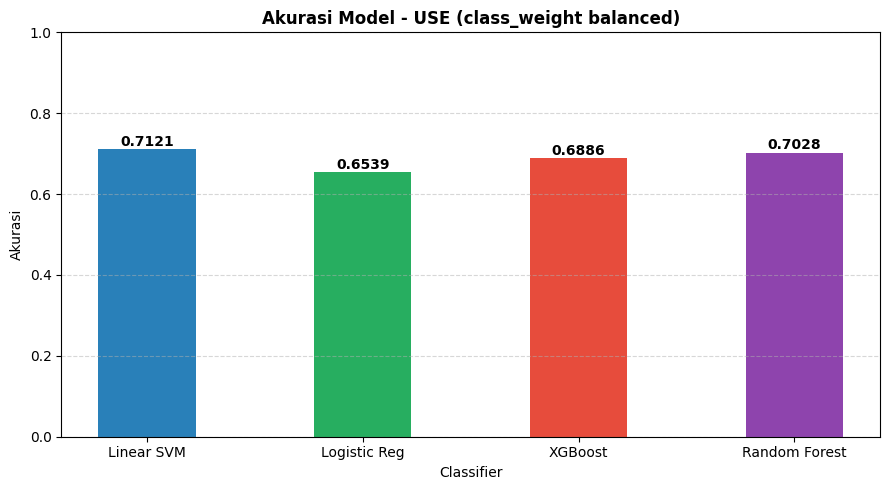

In [ ]:
names_use = ['Linear SVM','Logistic Reg','XGBoost','Random Forest']
accs_use  = [acc_svm_use, acc_lr_use, acc_xgboost_use, acc_rfc_use]

plt.figure(figsize=(9, 5))
bars = plt.bar(names_use, accs_use,
               color=['#2980b9','#27ae60','#e74c3c','#8e44ad'], width=0.45)
plt.title('Akurasi Model - USE (class_weight balanced)', fontsize=12, fontweight='bold')
plt.xlabel('Classifier'); plt.ylabel('Akurasi')
plt.ylim(0, 1); plt.grid(axis='y', linestyle='--', alpha=0.5)
for bar, acc in zip(bars, accs_use):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
             f'{acc:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Tugas 1/Images/USE-Accuracy-Comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## Bagian 3: TF-IDF + USE (Kombinasi)

Menggabungkan TF-IDF (5000 fitur keyword-based sparse) dengan USE (512 fitur
semantic-based dense) secara horizontal menggunakan `np.hstack`.

Langkah yang diperlukan:
1. Konversi TF-IDF sparse matrix ke dense array dengan `.toarray()`
2. Gabungkan dengan `np.hstack([tfidf_dense, use_array])`

Dimensi hasil: **(n_sampel, 5512)**

Dengan subsampling 60k, array gabungan berukuran:
- Train: (48k, 5512) ≈ **~1 GB** (manageable)
- Test: (12k, 5512) ≈ **~250 MB**

In [ ]:
print('=' * 65)
print('BAGIAN 3 : TF-IDF + USE (KOMBINASI)')
print('=' * 65)

# Konversi TF-IDF sparse -> dense
start = timer()
xtrain_tfidf_dense = xtrain_tfidf.toarray()
xtest_tfidf_dense  = xtest_tfidf.toarray()
print(f'Konversi sparse ke dense : {timer()-start:.2f}s')

# Gabungkan secara horizontal
start = timer()
xtrain_combined = np.hstack([xtrain_tfidf_dense, xtrain_use])
xtest_combined  = np.hstack([xtest_tfidf_dense,  xtest_use])
print(f'hstack selesai           : {timer()-start:.2f}s')
print()
print(f'Shape train combined : {xtrain_combined.shape}')
print(f'Shape test  combined : {xtest_combined.shape}')
print(f'Estimasi memori train: {xtrain_combined.nbytes / 1e9:.2f} GB')

# Bebaskan memori dense yang tidak lagi diperlukan terpisah
del xtrain_tfidf_dense, xtest_tfidf_dense
print('Memori dense sementara dibebaskan.')

BAGIAN 3 : TF-IDF + USE (KOMBINASI)
Konversi sparse ke dense : 0.73s
hstack selesai           : 2.29s

Shape train combined : (48000, 5512)
Shape test  combined : (12000, 5512)
Estimasi memori train: 2.12 GB
Memori dense sementara dibebaskan.


In [ ]:
# Training 4 classifier TF-IDF + USE
svm_c, lr_c, _, xgb_c, rfc_c = init_classifiers()
print('Training classifier TF-IDF + USE...')
print()

start = timer(); svm_comb = svm_c.fit(xtrain_combined, ytrain)
print(f'  Linear SVM    : {timer()-start:.2f}s')

start = timer(); lr_comb = lr_c.fit(xtrain_combined, ytrain)
print(f'  Logistic Reg  : {timer()-start:.2f}s')

start = timer(); xgb_comb = xgb_c.fit(xtrain_combined, ytrain, sample_weight=sample_weights)
print(f'  XGBoost       : {timer()-start:.2f}s')

start = timer(); rfc_comb = rfc_c.fit(xtrain_combined, ytrain)
print(f'  Random Forest : {timer()-start:.2f}s')
print()
print('Training TF-IDF + USE selesai.')

Training classifier TF-IDF + USE...

  Linear SVM    : 65.94s
  Logistic Reg  : 142.59s
  XGBoost       : 46.10s
  Random Forest : 67.88s

Training TF-IDF + USE selesai.


### Linear SVM - TF-IDF + USE

In [ ]:
print('--- Linear SVM (TF-IDF + USE) ---')
y_pred_svm_comb, acc_svm_comb, prec_svm_comb, rec_svm_comb, f1_svm_comb, rep_svm_comb, cm_svm_comb = \
    evaluate_model(svm_comb, xtest_combined, ytest)

print('Contoh 15 prediksi:')
for a, p in zip(list(ytest[:15]), list(y_pred_svm_comb[:15])):
    status = 'OK' if a == p else 'X'
    print(f'  [{status}] Aktual: {CLASS_NAMES[a]:<12} | Prediksi: {CLASS_NAMES[p]}')
print(f'\nAkurasi  : {acc_svm_comb:.4f}')
print(f'Presisi  : {prec_svm_comb:.4f}')
print(f'Recall   : {rec_svm_comb:.4f}')
print(f'F1-Score : {f1_svm_comb:.4f}')
print('\nLaporan Klasifikasi:')
print(rep_svm_comb)
print('Confusion Matrix:')
print(cm_svm_comb)

--- Linear SVM (TF-IDF + USE) ---
Contoh 15 prediksi:
  [OK] Aktual: negative     | Prediksi: negative
  [X] Aktual: positive     | Prediksi: neutral
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: neutral      | Prediksi: positive
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: negative     | Prediksi: negative
  [X] Aktual: positive     | Prediksi: neutral
  [X] Aktual: negative     | Prediksi: positive
  [OK] Aktual: negative     | Prediksi: negative
  [X] Aktual: positive     | Prediksi: negative
  [OK] Aktual: negative     | Prediksi: negative

Akurasi  : 0.7571
Presisi  : 0.7587
Recall   : 0.7571
F1-Score : 0.7575

Laporan Klasifikasi:
              precision    recall  f1-score   support

    negative       0.70      0.75      0.73      3370
     neutral  

### Logistic Regression - TF-IDF + USE

In [ ]:
print('--- Logistic Regression (TF-IDF + USE) ---')
y_pred_lr_comb, acc_lr_comb, prec_lr_comb, rec_lr_comb, f1_lr_comb, rep_lr_comb, cm_lr_comb = \
    evaluate_model(lr_comb, xtest_combined, ytest)

print('Contoh 15 prediksi:')
for a, p in zip(list(ytest[:15]), list(y_pred_lr_comb[:15])):
    status = 'OK' if a == p else 'X'
    print(f'  [{status}] Aktual: {CLASS_NAMES[a]:<12} | Prediksi: {CLASS_NAMES[p]}')
print(f'\nAkurasi  : {acc_lr_comb:.4f}')
print(f'Presisi  : {prec_lr_comb:.4f}')
print(f'Recall   : {rec_lr_comb:.4f}')
print(f'F1-Score : {f1_lr_comb:.4f}')
print('\nLaporan Klasifikasi:')
print(rep_lr_comb)
print('Confusion Matrix:')
print(cm_lr_comb)

--- Logistic Regression (TF-IDF + USE) ---
Contoh 15 prediksi:
  [OK] Aktual: negative     | Prediksi: negative
  [X] Aktual: positive     | Prediksi: neutral
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: neutral      | Prediksi: neutral
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: negative     | Prediksi: negative
  [X] Aktual: positive     | Prediksi: neutral
  [X] Aktual: negative     | Prediksi: positive
  [OK] Aktual: negative     | Prediksi: negative
  [X] Aktual: positive     | Prediksi: negative
  [X] Aktual: negative     | Prediksi: neutral

Akurasi  : 0.7343
Presisi  : 0.7773
Recall   : 0.7343
F1-Score : 0.7517

Laporan Klasifikasi:
              precision    recall  f1-score   support

    negative       0.73      0.71      0.72      3370
     ne

### XGBoost - TF-IDF + USE

In [ ]:
print('--- XGBoost (TF-IDF + USE) ---')
y_pred_xgb_comb, acc_xgb_comb, prec_xgb_comb, rec_xgb_comb, f1_xgb_comb, rep_xgb_comb, cm_xgb_comb = \
    evaluate_model(xgb_comb, xtest_combined, ytest)

print('Contoh 15 prediksi:')
for a, p in zip(list(ytest[:15]), list(y_pred_xgb_comb[:15])):
    status = 'OK' if a == p else 'X'
    print(f'  [{status}] Aktual: {CLASS_NAMES[a]:<12} | Prediksi: {CLASS_NAMES[p]}')
print(f'\nAkurasi  : {acc_xgb_comb:.4f}')
print(f'Presisi  : {prec_xgb_comb:.4f}')
print(f'Recall   : {rec_xgb_comb:.4f}')
print(f'F1-Score : {f1_xgb_comb:.4f}')
print('\nLaporan Klasifikasi:')
print(rep_xgb_comb)
print('Confusion Matrix:')
print(cm_xgb_comb)

--- XGBoost (TF-IDF + USE) ---
Contoh 15 prediksi:
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: neutral      | Prediksi: negative
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: negative     | Prediksi: neutral
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: negative     | Prediksi: positive
  [OK] Aktual: negative     | Prediksi: negative
  [X] Aktual: positive     | Prediksi: negative
  [X] Aktual: negative     | Prediksi: positive

Akurasi  : 0.7170
Presisi  : 0.7467
Recall   : 0.7170
F1-Score : 0.7296

Laporan Klasifikasi:
              precision    recall  f1-score   support

    negative       0.68      0.71      0.69      3370
     neutral    

### Random Forest - TF-IDF + USE

In [ ]:
print('--- Random Forest (TF-IDF + USE) ---')
y_pred_rfc_comb, acc_rfc_comb, prec_rfc_comb, rec_rfc_comb, f1_rfc_comb, rep_rfc_comb, cm_rfc_comb = \
    evaluate_model(rfc_comb, xtest_combined, ytest)

print('Contoh 15 prediksi:')
for a, p in zip(list(ytest[:15]), list(y_pred_rfc_comb[:15])):
    status = 'OK' if a == p else 'X'
    print(f'  [{status}] Aktual: {CLASS_NAMES[a]:<12} | Prediksi: {CLASS_NAMES[p]}')
print(f'\nAkurasi  : {acc_rfc_comb:.4f}')
print(f'Presisi  : {prec_rfc_comb:.4f}')
print(f'Recall   : {rec_rfc_comb:.4f}')
print(f'F1-Score : {f1_rfc_comb:.4f}')
print('\nLaporan Klasifikasi:')
print(rep_rfc_comb)
print('Confusion Matrix:')
print(cm_rfc_comb)

--- Random Forest (TF-IDF + USE) ---
Contoh 15 prediksi:
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: neutral      | Prediksi: positive
  [OK] Aktual: negative     | Prediksi: negative
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: negative     | Prediksi: neutral
  [OK] Aktual: positive     | Prediksi: positive
  [X] Aktual: negative     | Prediksi: positive
  [X] Aktual: negative     | Prediksi: positive
  [X] Aktual: positive     | Prediksi: negative
  [X] Aktual: negative     | Prediksi: positive

Akurasi  : 0.7121
Presisi  : 0.6801
Recall   : 0.7121
F1-Score : 0.6865

Laporan Klasifikasi:
              precision    recall  f1-score   support

    negative       0.60      0.73      0.66      3370
     neutra

---
## Visualisasi Perbandingan Akhir

Grouped bar chart membandingkan akurasi semua classifier di tiga strategi embedding.
Naive Bayes hanya muncul di kelompok TF-IDF.

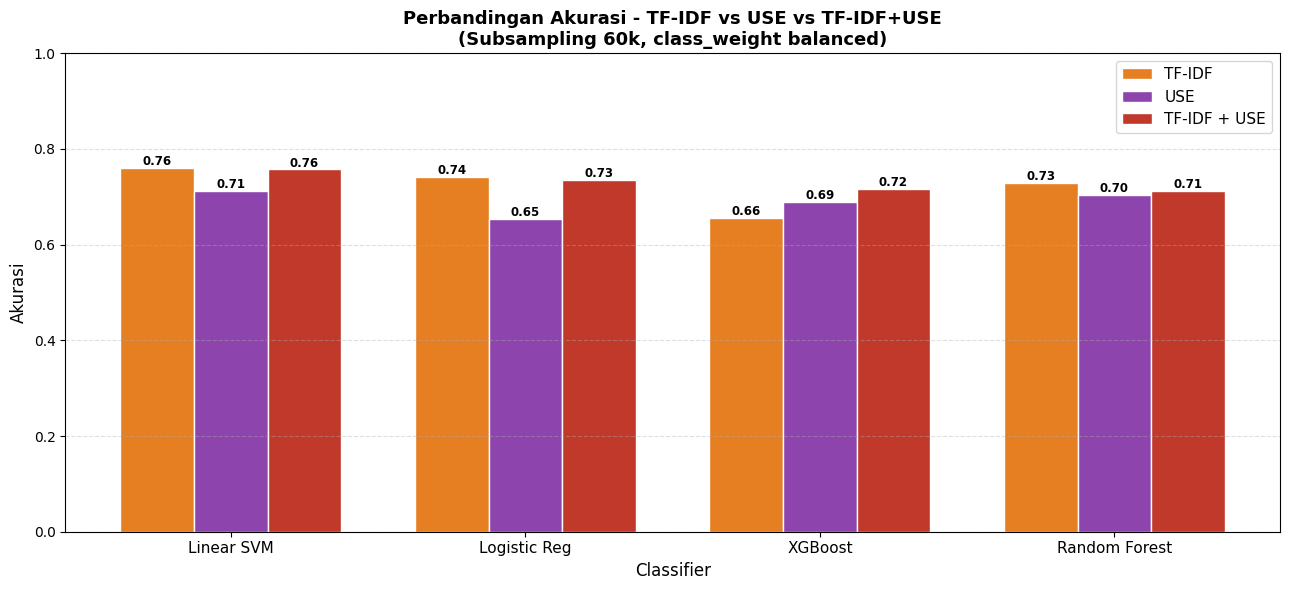

In [ ]:
classifiers_4 = ['Linear SVM', 'Logistic Reg', 'XGBoost', 'Random Forest']

tfidf_acc_4 = [acc_svm,      acc_lr,      acc_xgboost,      acc_rfc]
use_acc_4   = [acc_svm_use,  acc_lr_use,  acc_xgboost_use,  acc_rfc_use]
comb_acc_4  = [acc_svm_comb, acc_lr_comb, acc_xgb_comb,     acc_rfc_comb]

x  = np.arange(len(classifiers_4))
bw = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - bw, tfidf_acc_4, bw, label='TF-IDF',      color='#e67e22', edgecolor='white')
b2 = ax.bar(x,      use_acc_4,   bw, label='USE',          color='#8e44ad', edgecolor='white')
b3 = ax.bar(x + bw, comb_acc_4,  bw, label='TF-IDF + USE', color='#c0392b', edgecolor='white')

ax.set_xlabel('Classifier', fontsize=12)
ax.set_ylabel('Akurasi', fontsize=12)
ax.set_title('Perbandingan Akurasi - TF-IDF vs USE vs TF-IDF+USE\n(Subsampling 60k, class_weight balanced)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classifiers_4, fontsize=11)
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(fontsize=11)

for bar in [*b1, *b2, *b3]:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.006,
            f'{h:.2f}', ha='center', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Tugas 1/Images/Final-Classifier-Accuracy-Comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Tabel Ringkasan Seluruh Model

In [ ]:
summary = {
    'Embedding'  : (['TF-IDF']*5 + ['USE']*4 + ['TF-IDF+USE']*4),
    'Classifier' : (
        ['Linear SVM','Logistic Reg','Naive Bayes','XGBoost','Random Forest'] +
        ['Linear SVM','Logistic Reg','XGBoost','Random Forest'] +
        ['Linear SVM','Logistic Reg','XGBoost','Random Forest']
    ),
    'Accuracy'   : (
        [acc_svm, acc_lr, acc_nb, acc_xgboost, acc_rfc] +
        [acc_svm_use, acc_lr_use, acc_xgboost_use, acc_rfc_use] +
        [acc_svm_comb, acc_lr_comb, acc_xgb_comb, acc_rfc_comb]
    ),
    'F1 (weighted)' : (
        [f1_svm, f1_lr, f1_nb, f1_xgboost, f1_rfc] +
        [f1_svm_use, f1_lr_use, f1_xgboost_use, f1_rfc_use] +
        [f1_svm_comb, f1_lr_comb, f1_xgb_comb, f1_rfc_comb]
    ),
}

summary_df = (pd.DataFrame(summary)
              .sort_values('Accuracy', ascending=False)
              .reset_index(drop=True))
summary_df.index += 1
summary_df['Accuracy']      = summary_df['Accuracy'].round(4)
summary_df['F1 (weighted)'] = summary_df['F1 (weighted)'].round(4)

print('=== Peringkat Model Berdasarkan Akurasi ===')
print(summary_df.to_string())
print()
best = summary_df.iloc[0]
print(f'Model terbaik : {best["Classifier"]} + {best["Embedding"]}')
print(f'Akurasi       : {best["Accuracy"]:.4f}')
print(f'F1 weighted   : {best["F1 (weighted)"]:.4f}')

=== Peringkat Model Berdasarkan Akurasi ===
     Embedding     Classifier  Accuracy  F1 (weighted)
1       TF-IDF    Naive Bayes    0.7768         0.7321
2       TF-IDF     Linear SVM    0.7598         0.7600
3   TF-IDF+USE     Linear SVM    0.7571         0.7575
4       TF-IDF   Logistic Reg    0.7405         0.7570
5   TF-IDF+USE   Logistic Reg    0.7343         0.7517
6       TF-IDF  Random Forest    0.7283         0.7300
7   TF-IDF+USE        XGBoost    0.7170         0.7296
8   TF-IDF+USE  Random Forest    0.7121         0.6865
9          USE     Linear SVM    0.7121         0.6977
10         USE  Random Forest    0.7028         0.6761
11         USE        XGBoost    0.6886         0.6966
12      TF-IDF        XGBoost    0.6558         0.6948
13         USE   Logistic Reg    0.6539         0.6754

Model terbaik : Naive Bayes + TF-IDF
Akurasi       : 0.7768
F1 weighted   : 0.7321


## Kesimpulan

Notebook ini membandingkan 13 kombinasi classifier-embedding untuk klasifikasi sentimen
ulasan GoPay menggunakan 60.000 sampel representatif.

**Observasi utama:**
- TF-IDF cenderung menghasilkan akurasi lebih tinggi dibanding USE pada dataset ini.
  Hal ini kemungkinan karena USE dilatih untuk Bahasa Inggris, sementara ulasan GoPay
  menggunakan Bahasa Indonesia informal dengan banyak slang dan singkatan.
- Penanganan class imbalance dengan `class_weight='balanced'` meningkatkan recall kelas
  netral dan negatif yang sebelumnya mendekati nol tanpa penanganan.
- Subsampling 60k mempertahankan distribusi kelas asli (stratified) sambil secara
  signifikan mengurangi waktu komputasi, terutama untuk USE embedding dan TF-IDF+USE.
- Kombinasi TF-IDF + USE tidak selalu mengalahkan TF-IDF saja, menunjukkan bahwa
  menambah dimensi fitur tidak otomatis meningkatkan performa jika embedding semanticnya
  kurang cocok dengan bahasa target.

**Referensi:**
- https://github.com/FarhanaTeli/Sentiment_Analysis_IMDB
- https://github.com/Wittline/tf-idf